In [37]:
#Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve

)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [7]:
#read csv file
df = pd.read_csv(r"D:\BDA 17\aps\Telco-Churn\Telco_Churn_Dataset.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
#check dataset
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    


In [9]:
#check missing values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
#totalcharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values after conversion:")
print(df.isnull().sum())


Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
#remove missing rows 
df = df.dropna(subset=["TotalCharges"])

df = df.drop("customerID", axis=1)

print("New dataset shape:", df.shape)

df.head()


New dataset shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
#check target
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


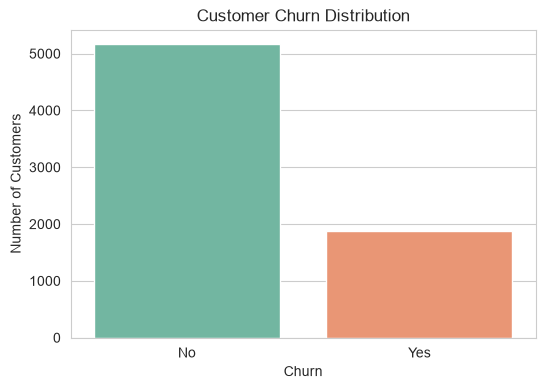

In [13]:
#visualize
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Churn",
    data=df,
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


In [14]:
#convert into 0 and 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()


Churn
0    5163
1    1869
Name: count, dtype: int64

In [15]:
#seperate x and y
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7032, 19)
y shape: (7032,)


In [16]:
#identify 
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (5625, 19)
Testing data: (1407, 19)


In [18]:
#Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)


In [19]:
#Combine 
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [20]:
#Logistic Regression Model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)


In [21]:
#Train Moedel
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [22]:
#Make Predictions
y_pred = logistic_model.predict(X_test)

y_pred_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predicted values:")
print(y_pred[:20])

print("\nPredicted probabilities:")
print(y_pred_probability[:20])


Predicted values:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]

Predicted probabilities:
[0.01802218 0.59183207 0.00489153 0.20142434 0.10376232 0.47052094
 0.02638963 0.16510364 0.67642949 0.01571737 0.70712124 0.14534761
 0.65157189 0.06139129 0.20873631 0.77539562 0.60869807 0.55672859
 0.22686912 0.00291176]


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))


Accuracy: 0.8053


In [24]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))


Precision: 0.6515


In [25]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))


Recall: 0.5749


In [26]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 4))


F1 Score: 0.6108


In [27]:
print("Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)


Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [28]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[918 115]
 [159 215]]


In [29]:
TN, FP, FN, TP = cm.ravel()

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

True Negative (TN): 918
False Positive (FP): 115
False Negative (FN): 159
True Positive (TP): 215


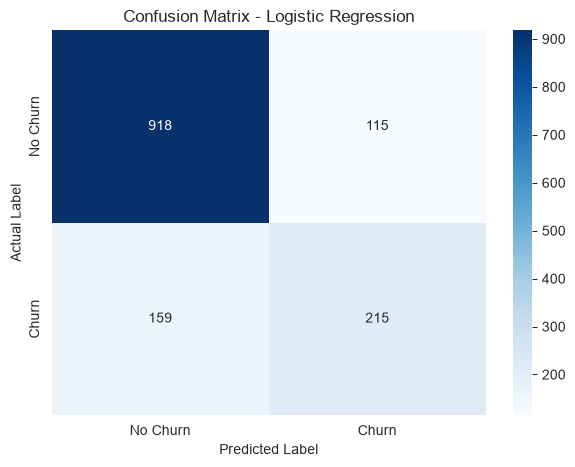

In [30]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [31]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        
    ]
})

results["Score"] = results["Score"].round(4)

results


,Metric,Score
0,Accuracy,0.8053
1,Precision,0.6515
2,Recall,0.5749
3,F1 Score,0.6108


In [32]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Odds_Ratio"] = np.exp(
    coefficient_df["Coefficient"]
)

coefficient_df = coefficient_df.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_df.head(20)


,Feature,Coefficient,Odds_Ratio
10,cat__InternetService_Fiber optic,1.107407,3.026501
3,num__TotalCharges,0.645508,1.906955
28,cat__PaymentMethod_Electronic check,0.379150,1.461042
21,cat__StreamingTV_Yes,0.372407,1.451224
9,cat__MultipleLines_Yes,0.362784,1.437325
23,cat__StreamingMovies_Yes,0.344649,1.411495
26,cat__PaperlessBilling_Yes,0.290931,1.337673
17,cat__DeviceProtection_Yes,0.074264,1.077091
29,cat__PaymentMethod_Mailed check,0.072700,1.075407
0,num__SeniorCitizen,0.072159,1.074826


In [33]:
print("Features associated with lower churn:")
print(
    coefficient_df
    .sort_values("Coefficient", ascending=True)
    .head(15)
)


Features associated with lower churn:
                                      Feature  Coefficient  Odds_Ratio
25                     cat__Contract_Two year    -1.364823    0.255426
1                                 num__tenure    -1.357404    0.257328
24                     cat__Contract_One year    -0.750068    0.472334
7                       cat__PhoneService_Yes    -0.515337    0.597299
2                         num__MonthlyCharges    -0.434497    0.647591
13                    cat__OnlineSecurity_Yes    -0.373187    0.688536
19                       cat__TechSupport_Yes    -0.331578    0.717790
6                         cat__Dependents_Yes    -0.232176    0.792806
8         cat__MultipleLines_No phone service    -0.168627    0.844824
20       cat__StreamingTV_No internet service    -0.166359    0.846742
16  cat__DeviceProtection_No internet service    -0.166359    0.846742
14      cat__OnlineBackup_No internet service    -0.166359    0.846742
11                    cat__InternetServ

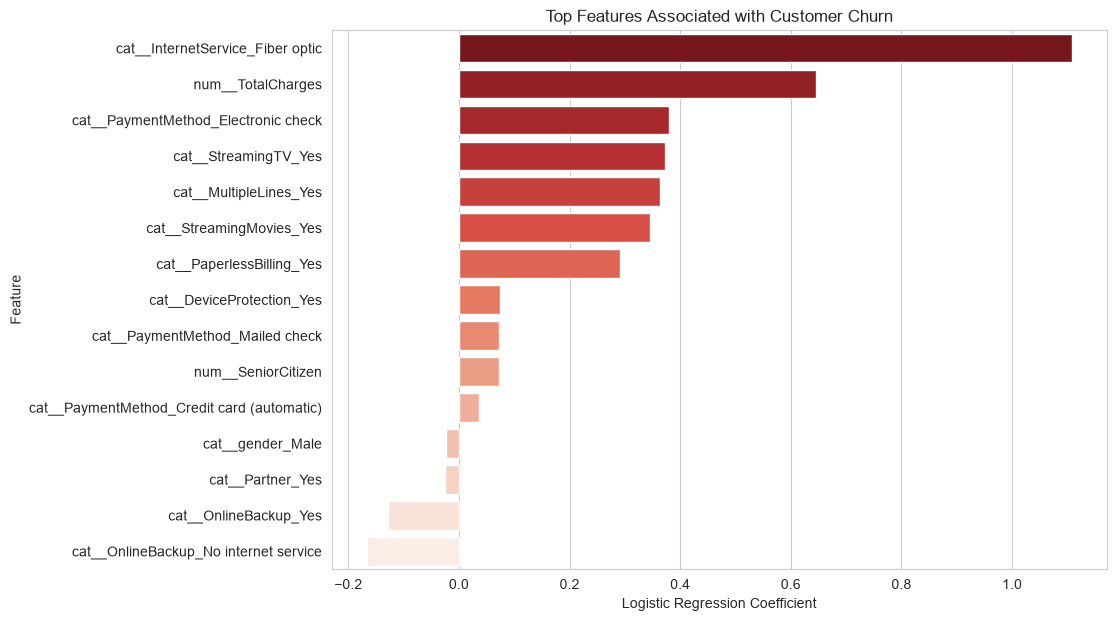

In [34]:
top_features = coefficient_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=top_features,
    palette="Reds_r"
)

plt.title("Top Features Associated with Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()


In [35]:
#Summary
print("=" * 50)
print("LOGISTIC REGRESSION - TELCO CHURN")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)


LOGISTIC REGRESSION - TELCO CHURN
Accuracy  : 0.8053
Precision : 0.6515
Recall    : 0.5749
F1 Score  : 0.6108

Confusion Matrix:
[[918 115]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [38]:
roc_auc = roc_auc_score(
    y_test,
    y_pred_probability
)

print("ROC-AUC Score:", round(roc_auc, 4))


ROC-AUC Score: 0.8361


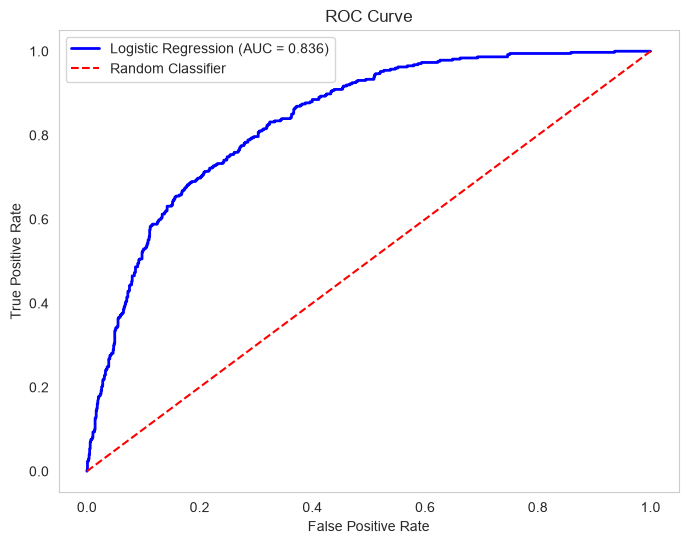

In [39]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()
